# Introduction to Data Access at NCI

This notebook focuses on:

1. Understanding what datasets are available
2. How to load data from one of these data sets
3. What "projects" you need to request to join
4. How you might need to adjust other tutorials to make use of NCI-cached data instead of cloud-sourced data

For those already familiar with joining projects for data access - you should join the following: dk92 (software), rv74 (Himawari), rt52 (ERA5), rq0 (radar), ob53 (BARRAv2).


Let's take a look at what is included in the 'site archive' for NCI.

In [1]:
import pyearthtools.data # This is where the data sets become "registered" so that you can have different sources of the same data

In [2]:
import site_archive_nci  # This is what gives you access to datasets cached at NCI
pyearthtools.data.archive.print_indexes(show_projects=True)  # Print all available indexes in the archive catalogue

<class 'site_archive_nci.ACCESS.ACCESS'> is a registered Index in the archive as pyearthtools.data.archive.ACCESS
<class 'site_archive_nci.AGCD.AGCD'> is a registered Index in the archive as pyearthtools.data.archive.AGCD
<class 'site_archive_nci._AusTopo.AusTopo'> is a registered Index in the archive as pyearthtools.data.archive.AusTopo
<class 'site_archive_nci.BARPA.BARPA'> is a registered Index in the archive as pyearthtools.data.archive.BARPA
<class 'site_archive_nci.BARRA.BARRA'> is a registered Index in the archive as pyearthtools.data.archive.BARRA
<class 'site_archive_nci.BARRAV2.BARRA_V2'> is a registered Index in the archive as pyearthtools.data.archive.BARRA_V2
<class 'site_archive_nci.BRAN.BRAN'> is a registered Index in the archive as pyearthtools.data.archive.BRAN
<class 'site_archive_nci._CMIP5.CMIP5'> is a registered Index in the archive as pyearthtools.data.archive.CMIP5
<class 'site_archive_nci.ERA5.ERA5'> is a registered Index in the archive as pyearthtools.data.arch

In [3]:
help(site_archive_nci)   # This will list out the data accessors which are coded for NCI-optimised data loading

Help on package site_archive_nci:

NAME
    site_archive_nci - National Computing Infrastructure specific Indexes

DESCRIPTION
    | Name        | Description |
    | :---        |       ----: |
    | [ERA5][site_archive_nci.ERA5]                | ECWMF ReAnalysis v5                                     |
    | [ACCESS][site_archive_nci.ACCESS]            | Australian Community Climate and Earth-System Simulator |
    | [AGCD][site_archive_nci.AGCD]                | Australian Gridded Climate Data                         |
    | [BRAN][site_archive_nci.BRAN]                | Bluelink ReANalysis                                     |
    | [OceanMaps][site_archive_nci.OceanMaps]      | Ocean Modelling and Analysis Prediction System          |
    | [MODIS][site_archive_nci.MODIS]              | MODerate resolution Imaging Spectroradiometer           |
    | [Himawari][site_archive_nci.Himawari]        | Himawari 8/9 satellite data                             |
    | [Rainfields3][site_arc

In [4]:
pyearthtools.data.archive.ERA5  # Here we see that the NCI site archive data has been "registered" into pyearthtools.data.archive. 
                                # In other facilities, you will need to import a different 'site archive' but you can still access it by the same name

site_archive_nci.ERA5.ERA5

# Exploring a Data Source

ERA5 has a very complex data structure. It has different "products" with different variables in them - there is no simple listing of the available variables for this particular source. The data accessor needs to know what variables you want in order to find them on disk, so it can't just present you with a catalogue. In this tutorial, we will look at a 'cube' of the data from the (default) 'reanalysis' product that includes vertical levels, as well as a single-level near-surface view which only includes a single level taken from near the surface of the Earth. Detailed exploration of the data accessor variables and structure are beyond the scope of this tutorial series. If you want to read further on what ERA5 is, what fields are available, and what the nuances of the data are, read the official documentation at  https://doi.org/10.24381/cds.adbb2d47 .

For the purposes of this tutorial, just focus on the plots. We are accessing weather data for basic parameters of interest to people - temperature and wind.

In [5]:
data_cube_index = pyearthtools.data.archive.ERA5(variables=['t', 'u', 'v'])

In [6]:
data_cube_index['2010-01-01T0600']  # Don't try to load it all at once! A few time steps is fine, maybe up to 3 days or so

/g/data/kd24/tjl/src/PyEarthTools/packages/data/src/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


<xarray.Dataset> Size: 922MB
Dimensions:    (time: 1, level: 37, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2010-01-01T06:00:00
  * level      (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    t          (time, level, latitude, longitude) float64 307MB dask.array<chunksize=(1, 5, 405, 900), meta=np.ndarray>
    u          (time, level, latitude, longitude) float64 307MB dask.array<chunksize=(1, 5, 405, 900), meta=np.ndarray>
    v          (time, level, latitude, longitude) float64 307MB dask.array<chunksize=(1, 5, 405, 900), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...

# Understanding Vertical Structure

We can see this example includes the "level" coordinate, which are like 37 'layers' of data laid one on top of the other, with the top of the pile being the outer atmosphere, and the bottom of the pile being near-surface. There is a specific level, the "skin" level, which is right where the atmosphere meets the ground. You would need to refer to the ERA5 documentation to understand the exact semantics of the data here, but in general the level here refers to a "pressure" level. The 1000 hPa pressure level is the surface (high pressure), and the 1 hPa level (low pressure) is the top. There are complicating factors as well, such as mountains that stick up through the pressure levels, which in ERA5 are infilled. Working with any data set requires strong data understanding.

For this tutorial series, we will work with a subset of near-surface, single-level data, and we will overlook the nuances of how topography interacts. In this case, the semantics of the numbers is a little different. '2t' refers to the temperature 2 metres above ground level, '10u' is the north/south wind speed, and '10v' is the east/west wind speed, at 10 metres above ground level. Why it's called U and V and not "N" and "W", I don't know. 

Typically, either you're working with vertical levels or you are working with so-called surface data, and they're accessed slightly differently. For simplicity's sake, we will stick with surface data for now, but it's important to acknowledge the two data structures.

In [7]:
data_nearsurface_index = pyearthtools.data.archive.ERA5(variables=['2t', '10u', '10v'])

In [8]:
data_nearsurface_index['2010-01-01T0600']

/g/data/kd24/tjl/src/PyEarthTools/packages/data/src/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


<xarray.Dataset> Size: 25MB
Dimensions:    (time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2010-01-01T06:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    2t         (time, latitude, longitude) float64 8MB dask.array<chunksize=(1, 182, 360), meta=np.ndarray>
    10u        (time, latitude, longitude) float64 8MB dask.array<chunksize=(1, 182, 360), meta=np.ndarray>
    10v        (time, latitude, longitude) float64 8MB dask.array<chunksize=(1, 182, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...

/g/data/kd24/tjl/src/PyEarthTools/packages/data/src/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


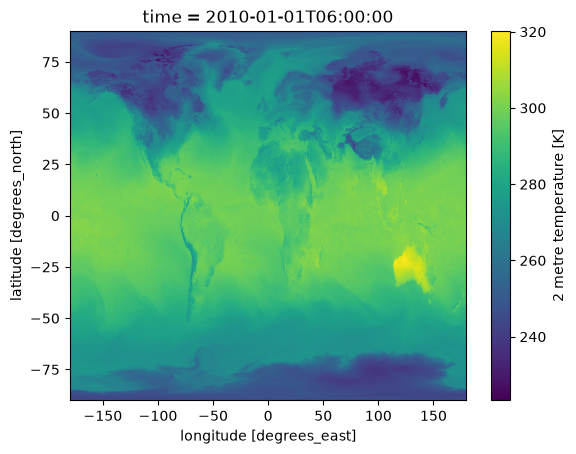

In [9]:
data_nearsurface_index['2010-01-01T0600']['2t'].plot()

# How To Use This

Some of the tutorial examples are written to use a cloud-sourced version of ERA5, which is downloaded each time from the Internet. That uses a slightly different data accessor, called pyearthtools.data.download.weatherbench.WB2ERA5. It is stored online with a slightly different data structure, and with different names for the same data variables. In an ideal world, there would be a simple way to standardise these two data sets. In practise, for the moment, it is still up to the user to handle the difference. The cloud-hosted version is optimised for a specific use case, which is different to the representation on-disk at HPC facilities.

As a result, you might need to modify the example notebooks to use the NCI-cached dataset. Many of the tutorials are written with people working at a wide variety of facilities, which may not have a pre-fetched version of the ERA5 data. For those people, the cloud-based data is more convenient. You will need to get to know your data sets well in any case. For these tutorials, however, the notebooks themselves include the instructions needed to switch between cloud-based and NCI-cached data.

# Himawari 8/9 Data

The next data set we will work with comes from satellite observations. In the Australian region, one of the most important satellites is called Himawari. Since the data structure on disk is simpler, we don't need to know the variables up-front, and can just go straight to data access.

In [10]:
pyearthtools.data.archive.Himawari()['20240203T00']

/g/data/kd24/tjl/src/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:326: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  full_ds = xr.open_mfdataset(


<xarray.Dataset> Size: 2GB
Dimensions:                     (time: 6, latitude: 1726, longitude: 2214)
Coordinates:
  * time                        (time) datetime64[ns] 48B 2024-02-03 ... 2024...
  * latitude                    (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                   (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    crs                         (time) int32 24B -2147483647 ... -2147483647
    surface_global_irradiance   (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    direct_normal_irradiance    (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    surface_diffuse_irradiance  (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    quality_mask                (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    cloud_type                  (time, latitude, longitude) float32 92MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    cloud_optical_depth         (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    solar_elevation             (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    solar_azimuth               (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    julian_date                 (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/52)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    geospatial_lon_resolution:        0.02
    bias_correction_applied:          1
    bias_correction_applied_meaning:  0: not applied; 1:applied
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    history:                          heliosat-4; post_process_p1s.py

# Data Description

Here, we get back an xarray object with 6 time-steps in it. In the next cell, you can see how we use a more precise time query to get the exact slice of interest. We could have taken it from the 6-step object, but it's an opportunity to demonstrate the flexible time matching implemented by the data accessors. 

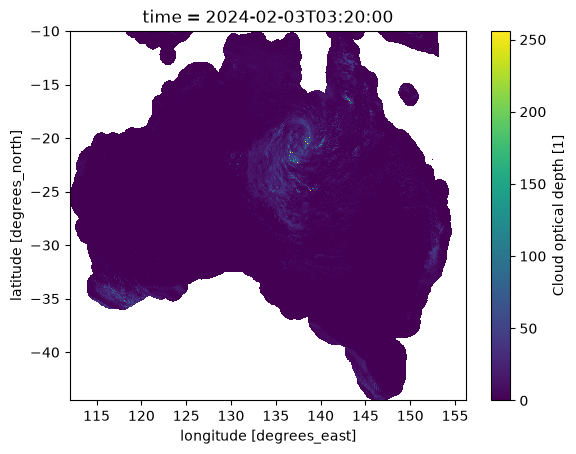

In [11]:
pyearthtools.data.archive.Himawari()['20240203T03:20']['cloud_optical_depth'].plot()